# COVID-19 Data: Cleaning, Merging & Analysis (4-file version)

This notebook combines four OWID COVID-19 exports into a single analytical dataset:

- `total_deaths.csv` — wide format (1 row per date, 1 column per country), daily cumulative deaths
- `total_deaths_per_million.csv` — same wide format, deaths per million
- `total_cases_per_million.csv` — same wide format, cases per million
- `owid-covid-data.csv` — long format (1 row per country-date), with demographic/economic
  country characteristics (population, GDP per capita, HDI, life expectancy, etc.)

**Strategy**

The three wide files share the same date range (2020–2024) and just need to be reshaped
("melted") into long format and joined to each other on `date` + `location`.

The `owid-covid-data.csv` file here only covers a short early window (through Sep 2020), but
the columns we actually want from it — population, GDP per capita, HDI, etc. — are static
country characteristics that don't change day to day. So instead of merging it on
`date` + `location` (which would only keep 2020 data), we take **one snapshot row per country**
from it and merge that onto the full daily time series using `location` alone. This way we get
the complete 2020–2024 case/death time series *and* the country context, with no data lost.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load the three wide-format time series files

In [8]:
deaths = pd.read_csv('total_deaths.csv', parse_dates=['date'])
deaths_pm = pd.read_csv('total_deaths_per_million.csv', parse_dates=['date'])
cases_pm = pd.read_csv('total_cases_per_million.csv', parse_dates=['date'])

print('total_deaths.csv:', deaths.shape)
print('total_deaths_per_million.csv:', deaths_pm.shape)
print('total_cases_per_million.csv:', cases_pm.shape)
deaths.head()


total_deaths.csv: (1674, 247)
total_deaths_per_million.csv: (1674, 247)
total_cases_per_million.csv: (1674, 247)


,date,World,Afghanistan,Africa,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,Aruba,Asia,Australia,Austria,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bermuda,Bhutan,Bolivia,Bonaire Sint Eustatius and Saba,...,Syria,Tajikistan,Tanzania,Thailand,Togo,Tokelau,Tonga,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Turks and Caicos Islands,Tuvalu,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States,United States Virgin Islands,Upper-middle-income countries,Uruguay,Uzbekistan,Vanuatu,Vatican,Venezuela,Vietnam,Wallis and Futuna,Yemen,Zambia,Zimbabwe
0,2020-01-05,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2020-01-06,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2020-01-07,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2020-01-08,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2020-01-09,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Reshape wide -> long
Each wide file has `date` plus one column per country/region. Melt each into
`date, location, value`, then join the three metrics together.


In [9]:
def wide_to_long(df, value_name):
    long_df = df.melt(id_vars='date', var_name='location', value_name=value_name)
    return long_df

deaths_long = wide_to_long(deaths, 'total_deaths')
deaths_pm_long = wide_to_long(deaths_pm, 'total_deaths_per_million')
cases_pm_long = wide_to_long(cases_pm, 'total_cases_per_million')

# Join the three metrics on date + location
timeseries = deaths_long.merge(deaths_pm_long, on=['date', 'location'], how='outer')
timeseries = timeseries.merge(cases_pm_long, on=['date', 'location'], how='outer')

print('Combined long time series shape:', timeseries.shape)
timeseries.head()


Combined long time series shape: (411804, 5)


,date,location,total_deaths,total_deaths_per_million,total_cases_per_million
0,2020-01-05,Afghanistan,0,0.0,0.0
1,2020-01-05,Africa,0,0.0,0.0
2,2020-01-05,Albania,0,0.0,0.0
3,2020-01-05,Algeria,0,0.0,0.0
4,2020-01-05,American Samoa,0,0.0,0.0


## 3. Clean the combined time series
- Drop aggregate/non-country rows (continents, income groups, "World") to isolate country-level analysis
- Sort and forward-fill within each country (these are cumulative metrics)


In [10]:
NON_COUNTRY_LOCATIONS = [
    'World', 'Africa', 'Asia', 'Europe', 'European Union (27)', 'North America', 'Oceania',
    'South America', 'High-income countries', 'Low-income countries',
    'Lower-middle-income countries', 'Upper-middle-income countries'
]

timeseries_clean = timeseries.drop_duplicates().sort_values(['location', 'date'])

# Keep a version with aggregates (useful for global-level charts) ...
timeseries_with_aggregates = timeseries_clean.copy()

# ... and a country-only version for country-level analysis
timeseries_countries = timeseries_clean[~timeseries_clean['location'].isin(NON_COUNTRY_LOCATIONS)].copy()

# Forward-fill cumulative metrics within each location (they shouldn't decrease day to day)
metric_cols = ['total_deaths', 'total_deaths_per_million', 'total_cases_per_million']
for df in (timeseries_with_aggregates, timeseries_countries):
    df[metric_cols] = df.groupby('location')[metric_cols].ffill()

print('Country-level time series shape:', timeseries_countries.shape)
timeseries_countries.isna().mean()


Country-level time series shape: (391716, 5)


date                        0.0
location                    0.0
total_deaths                0.0
total_deaths_per_million    0.0
total_cases_per_million     0.0
dtype: float64

## 4. Load and clean `owid-covid-data.csv` for country characteristics
We only need the mostly-static columns (population, demographics, economics), not the
day-by-day case/death columns, since those already came from the wide files above.


In [11]:
owid = pd.read_csv('owid-covid-data.csv', parse_dates=['date'])
print('owid-covid-data.csv:', owid.shape)
print('Date range:', owid['date'].min().date(), 'to', owid['date'].max().date())

# Drop aggregate rows (keep only rows with a continent, i.e. real countries)
owid_countries = owid[owid['continent'].notna()].copy()

static_cols = [
    'location', 'continent', 'population', 'population_density', 'median_age',
    'aged_65_older', 'aged_70_older', 'gdp_per_capita', 'extreme_poverty',
    'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers', 'male_smokers',
    'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy',
    'human_development_index'
]

# One row per country: take the most recently reported non-null value for each static column
country_context = (
    owid_countries.sort_values('date')
    .groupby('location')[static_cols[1:]]  # exclude 'location' itself from agg
    .last()
    .reset_index()
)

print('Country context shape:', country_context.shape)
country_context.head()


owid-covid-data.csv: (44785, 41)
Date range: 2019-12-31 to 2020-09-19
Country context shape: (210, 17)


,location,continent,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,Afghanistan,Asia,38928341.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.50,64.83,0.498
1,Albania,Europe,2877800.0,104.871,38.0,13.188,8.643,11803.431,1.1,304.195,10.08,7.1,51.2,NaN,2.89,78.57,0.785
2,Algeria,Africa,43851043.0,17.348,29.1,6.211,3.857,13913.839,0.5,278.364,6.73,0.7,30.4,83.741,1.90,76.88,0.754
3,Andorra,Europe,77265.0,163.755,NaN,NaN,NaN,NaN,NaN,109.135,7.97,29.0,37.8,NaN,NaN,83.73,0.858
4,Angola,Africa,32866268.0,23.890,16.8,2.405,1.362,5819.495,NaN,276.045,3.94,NaN,NaN,26.664,NaN,61.15,0.581


## 5. Merge everything together
Join the full daily case/death time series to the (static) country context on `location` only.
This preserves every date in the time series regardless of what period `owid-covid-data.csv` covers.


In [12]:
merged = timeseries_countries.merge(country_context, on='location', how='left')

print('Final merged shape:', merged.shape)
match_rate = merged['population'].notna().mean()
print(f'{match_rate:.1%} of rows matched to country context (population, GDP, HDI, etc.)')
merged.head()


Final merged shape: (391716, 21)
86.3% of rows matched to country context (population, GDP, HDI, etc.)


,date,location,total_deaths,total_deaths_per_million,total_cases_per_million,continent,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,2020-01-05,Afghanistan,0,0.0,0.0,Asia,38928341.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,2020-01-06,Afghanistan,0,0.0,0.0,Asia,38928341.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,2020-01-07,Afghanistan,0,0.0,0.0,Asia,38928341.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,2020-01-08,Afghanistan,0,0.0,0.0,Asia,38928341.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,2020-01-09,Afghanistan,0,0.0,0.0,Asia,38928341.0,54.422,18.6,2.581,1.337,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


## 6. Analysis

### 6.1 Global daily trend: total deaths per million (selected large countries)

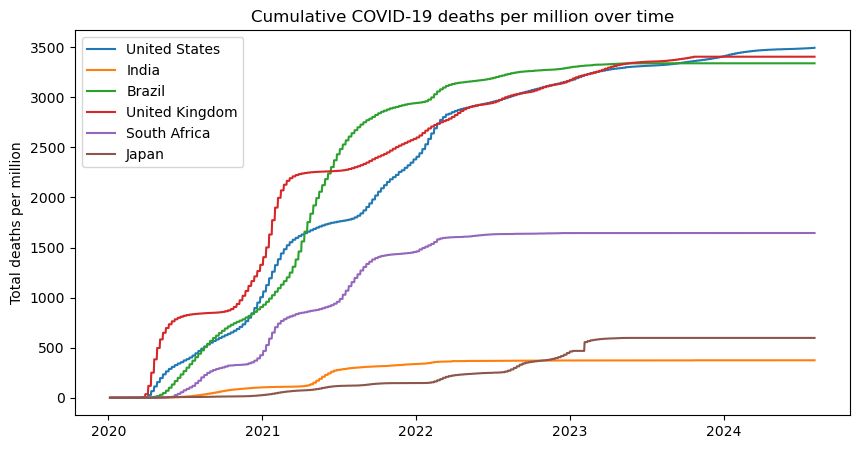

In [13]:
countries_of_interest = ['United States', 'India', 'Brazil', 'United Kingdom', 'South Africa', 'Japan']

subset = merged[merged['location'].isin(countries_of_interest)]

for loc in countries_of_interest:
    sub = subset[subset['location'] == loc]
    plt.plot(sub['date'], sub['total_deaths_per_million'], label=loc)

plt.legend()
plt.ylabel('Total deaths per million')
plt.title('Cumulative COVID-19 deaths per million over time')
plt.show()


### 6.2 Top 15 countries by total deaths per million (latest date per country)

In [14]:
latest = (
    merged.sort_values('date')
    .groupby('location')
    .tail(1)
    .dropna(subset=['total_deaths_per_million'])
)

top15 = latest.nlargest(15, 'total_deaths_per_million')[['location', 'date', 'total_deaths_per_million']]
top15


,location,date,total_deaths_per_million
276209,Peru,2024-08-04,6601.110
53567,Bulgaria,2024-08-04,5669.613
259469,North Macedonia,2024-08-04,5422.131
45197,Bosnia and Herzegovina,2024-08-04,5114.820
157355,Hungary,2024-08-04,5065.206
83699,Croatia,2024-08-04,4799.552
324755,Slovenia,2024-08-04,4766.858
130571,Georgia,2024-08-04,4519.362
232685,Montenegro,2024-08-04,4317.904
90395,Czechia,2024-08-04,4076.466


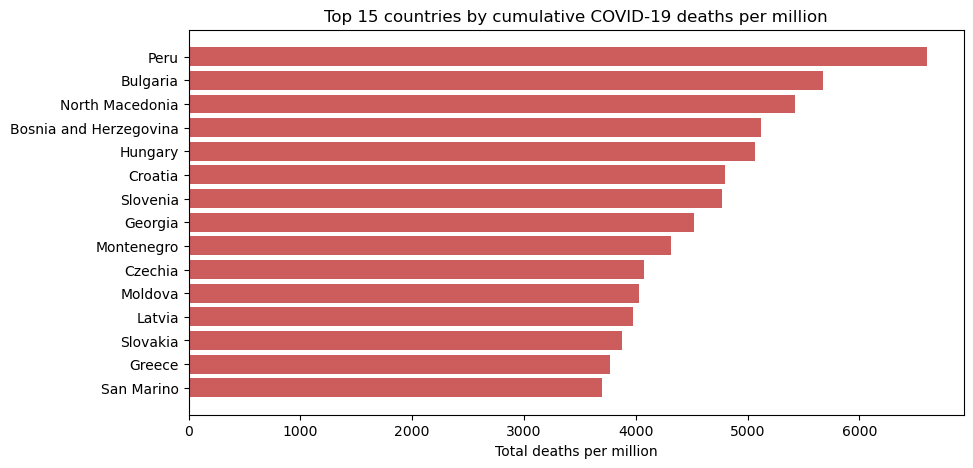

In [15]:
plt.barh(top15['location'], top15['total_deaths_per_million'], color='indianred')
plt.xlabel('Total deaths per million')
plt.title('Top 15 countries by cumulative COVID-19 deaths per million')
plt.gca().invert_yaxis()
plt.show()


### 6.3 Does wealth (GDP per capita) relate to deaths per million?

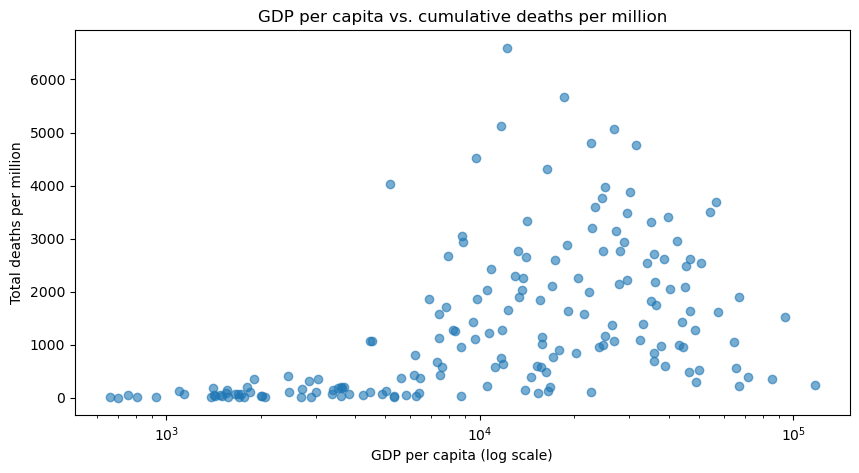

Correlation (GDP per capita vs deaths per million): 0.2665012103031414


In [16]:
scatter_df = latest.dropna(subset=['gdp_per_capita', 'total_deaths_per_million'])

plt.scatter(scatter_df['gdp_per_capita'], scatter_df['total_deaths_per_million'], alpha=0.6)
plt.xscale('log')
plt.xlabel('GDP per capita (log scale)')
plt.ylabel('Total deaths per million')
plt.title('GDP per capita vs. cumulative deaths per million')
plt.show()

print('Correlation (GDP per capita vs deaths per million):',
      scatter_df['gdp_per_capita'].corr(scatter_df['total_deaths_per_million']))


### 6.4 Does median age relate to deaths per million?

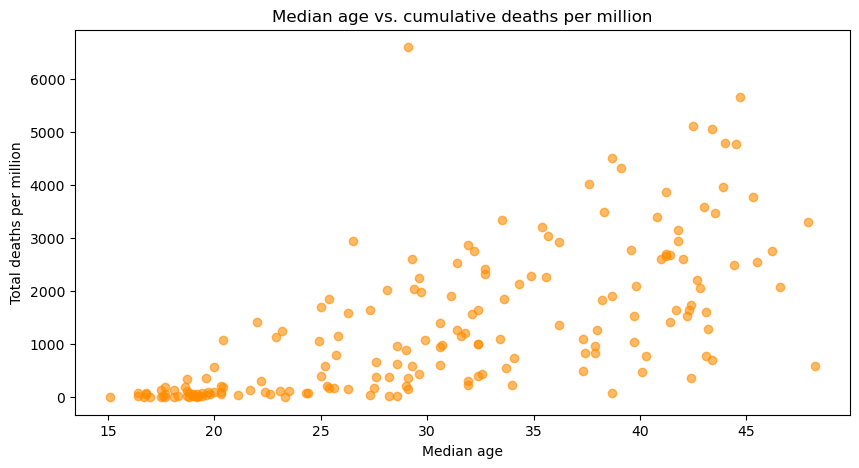

Correlation (median age vs deaths per million): 0.6706138330356504


In [17]:
age_df = latest.dropna(subset=['median_age', 'total_deaths_per_million'])

plt.scatter(age_df['median_age'], age_df['total_deaths_per_million'], alpha=0.6, color='darkorange')
plt.xlabel('Median age')
plt.ylabel('Total deaths per million')
plt.title('Median age vs. cumulative deaths per million')
plt.show()

print('Correlation (median age vs deaths per million):',
      age_df['median_age'].corr(age_df['total_deaths_per_million']))


### 6.5 Case fatality proxy: deaths per million vs cases per million, by continent

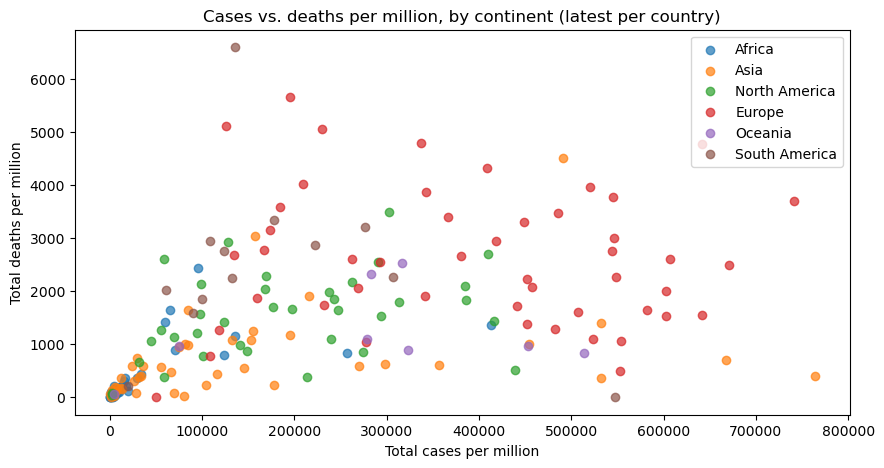

In [18]:
cfr_df = latest.dropna(subset=['total_cases_per_million', 'total_deaths_per_million', 'continent'])

fig, ax = plt.subplots()
for cont in cfr_df['continent'].unique():
    sub = cfr_df[cfr_df['continent'] == cont]
    ax.scatter(sub['total_cases_per_million'], sub['total_deaths_per_million'], label=cont, alpha=0.7)

ax.set_xlabel('Total cases per million')
ax.set_ylabel('Total deaths per million')
ax.set_title('Cases vs. deaths per million, by continent (latest per country)')
ax.legend()
plt.show()


In [19]:
### 6.6 Global aggregate trend (using the 'World' row from the wide files)

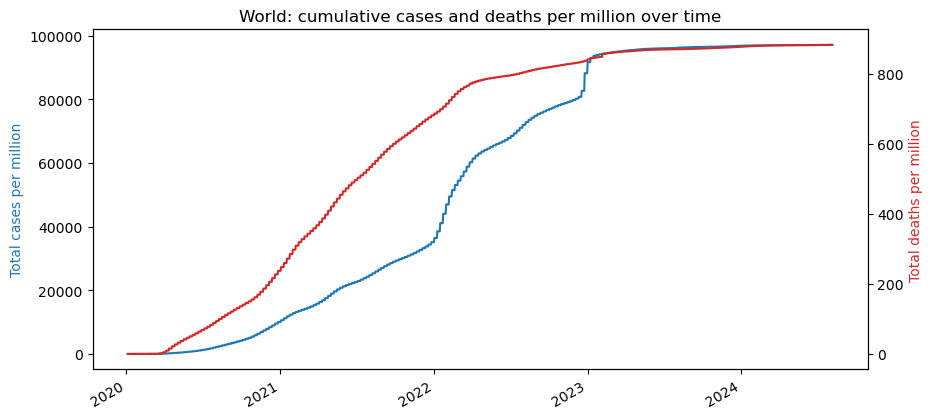

In [20]:
world = timeseries_with_aggregates[timeseries_with_aggregates['location'] == 'World']

fig, ax1 = plt.subplots()
ax1.plot(world['date'], world['total_cases_per_million'], color='tab:blue', label='Cases per million')
ax1.set_ylabel('Total cases per million', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(world['date'], world['total_deaths_per_million'], color='tab:red', label='Deaths per million')
ax2.set_ylabel('Total deaths per million', color='tab:red')
plt.title('World: cumulative cases and deaths per million over time')
fig.autofmt_xdate()
plt.show()


## 7. Export cleaned & merged datab

In [21]:
timeseries_countries.to_csv('covid_timeseries_countries_cleaned.csv', index=False)
country_context.to_csv('country_context_cleaned.csv', index=False)
merged.to_csv('covid_full_merged.csv', index=False)
print('Saved: covid_timeseries_countries_cleaned.csv, country_context_cleaned.csv, covid_full_merged.csv')


Saved: covid_timeseries_countries_cleaned.csv, country_context_cleaned.csv, covid_full_merged.csv


## 7. Clustering: grouping countries by pandemic profile
We use k-means to group countries by their pandemic outcome + demographic/economic profile,
using each country's latest cumulative figures alongside its static characteristics.


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_features = [
    'total_deaths_per_million', 'total_cases_per_million', 'median_age', 'gdp_per_capita',
    'population_density', 'hospital_beds_per_thousand', 'human_development_index'
]

cluster_df = latest.dropna(subset=cluster_features).copy()
print(f'Countries with complete data for clustering: {len(cluster_df)}')

X = cluster_df[cluster_features]
X_scaled = StandardScaler().fit_transform(X)


Countries with complete data for clustering: 152


In [23]:
### 7.1 Choose the number of clusters (elbow method)

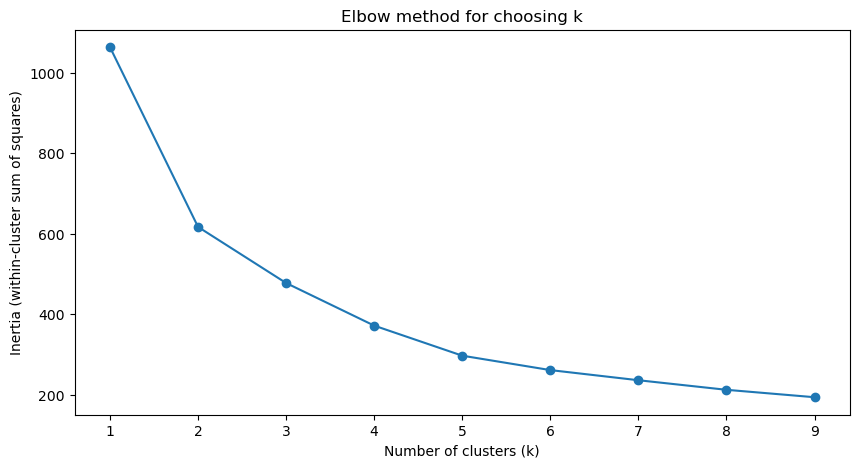

In [24]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow method for choosing k')
plt.show()


### 7.2 Fit k-means and visualize
We use k=4 as a reasonable starting point based on the elbow curve above (adjust if the elbow
suggests a different value once you see your own data).


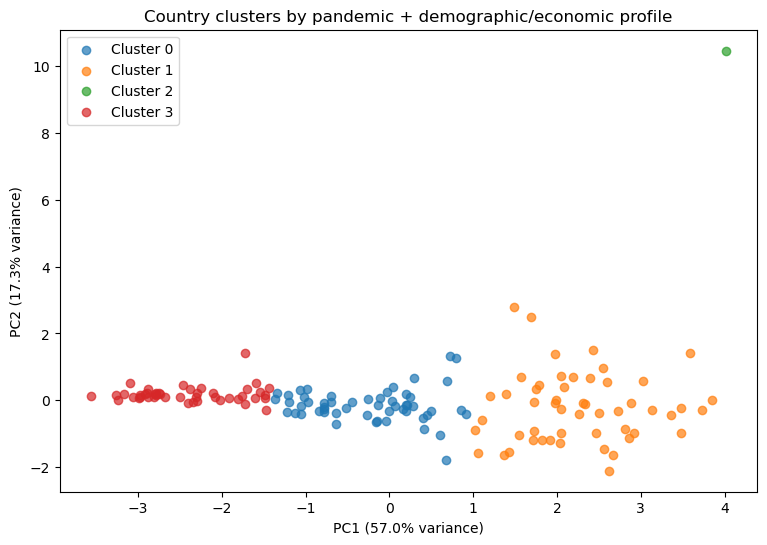

In [25]:
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

# Project to 2D with PCA purely for visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
cluster_df['pca_x'] = coords[:, 0]
cluster_df['pca_y'] = coords[:, 1]

plt.figure(figsize=(9, 6))
for c in sorted(cluster_df['cluster'].unique()):
    sub = cluster_df[cluster_df['cluster'] == c]
    plt.scatter(sub['pca_x'], sub['pca_y'], label=f'Cluster {c}', alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Country clusters by pandemic + demographic/economic profile')
plt.legend()
plt.show()


In [26]:
# What characterizes each cluster? Compare average feature values
cluster_summary = cluster_df.groupby('cluster')[cluster_features].mean().round(1)
cluster_summary['n_countries'] = cluster_df.groupby('cluster').size()
cluster_summary


,total_deaths_per_million,total_cases_per_million,median_age,gdp_per_capita,population_density,hospital_beds_per_thousand,human_development_index,n_countries
cluster,,,,,,,,
0,1415.6,110742.2,30.7,16997.0,122.4,2.6,0.7,54
1,2519.2,387090.6,40.7,36362.7,196.3,4.9,0.9,52
2,358.2,532073.6,42.4,85535.4,7915.7,2.4,0.9,1
3,181.6,13432.1,21.2,3915.7,148.5,1.0,0.5,45


In [27]:
# Which countries fall in each cluster?
for c in sorted(cluster_df['cluster'].unique()):
    countries_in_cluster = cluster_df[cluster_df['cluster'] == c].sort_values(
        'total_deaths_per_million', ascending=False
    )['location'].tolist()
    print(f'--- Cluster {c} ({len(countries_in_cluster)} countries) ---')
    print(', '.join(countries_in_cluster[:15]), '...' if len(countries_in_cluster) > 15 else '')
    print()


--- Cluster 0 (54 countries) ---
Peru, Brazil, Armenia, Paraguay, Trinidad and Tobago, Colombia, Mexico, Tunisia, Saint Lucia, Uruguay, Suriname, Bahamas, Grenada, Ecuador, Panama ...

--- Cluster 1 (52 countries) ---
Bulgaria, Bosnia and Herzegovina, Hungary, Croatia, Slovenia, Georgia, Montenegro, Moldova, Latvia, Slovakia, Greece, Romania, United States, Lithuania, United Kingdom ...

--- Cluster 2 (1 countries) ---
Singapore 

--- Cluster 3 (45 countries) ---
Guatemala, Honduras, Philippines, Iraq, Nepal, India, Myanmar, Zimbabwe, Sao Tome and Principe, Egypt, Zambia, Afghanistan, Comoros, Cambodia, Bangladesh ...



## 8. Regression: what predicts deaths per million?
A single multiple regression is more rigorous than the pairwise correlations from Section 6,
since it controls for all predictors simultaneously.


In [28]:
import statsmodels.api as sm

reg_features = [
    'median_age', 'gdp_per_capita', 'population_density',
    'hospital_beds_per_thousand', 'human_development_index'
]

reg_df = latest.dropna(subset=reg_features + ['total_deaths_per_million']).copy()
print(f'Countries with complete data for regression: {len(reg_df)}')

X_reg = reg_df[reg_features]
X_reg = sm.add_constant(X_reg)
y_reg = reg_df['total_deaths_per_million']

model = sm.OLS(y_reg, X_reg).fit()
print(model.summary())


Countries with complete data for regression: 152
                               OLS Regression Results                               
Dep. Variable:     total_deaths_per_million   R-squared:                       0.517
Model:                                  OLS   Adj. R-squared:                  0.500
Method:                       Least Squares   F-statistic:                     31.20
Date:                      Thu, 16 Jul 2026   Prob (F-statistic):           1.65e-21
Time:                              16:16:41   Log-Likelihood:                -1263.0
No. Observations:                       152   AIC:                             2538.
Df Residuals:                           146   BIC:                             2556.
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------

### 8.1 Interpreting the coefficients
- A **positive** coefficient means higher values of that predictor are associated with higher
  deaths per million, holding the other predictors constant.
- The **p-value** (`P>|t|`) tells you whether that relationship is statistically significant
  (conventionally, p < 0.05).
- **R-squared** tells you what share of the variation in deaths per million is explained by
  this set of predictors combined.


In [29]:
coef_summary = pd.DataFrame({
    'coefficient': model.params,
    'p_value': model.pvalues
}).drop('const')
coef_summary['significant (p<0.05)'] = coef_summary['p_value'] < 0.05
coef_summary


,coefficient,p_value,significant (p<0.05)
median_age,130.771536,2.972349e-08,True
gdp_per_capita,-0.026082,9.501487e-05,True
population_density,-0.244338,5.761028e-02,False
hospital_beds_per_thousand,-78.027946,1.052949e-01,False
human_development_index,1851.583267,1.901079e-01,False


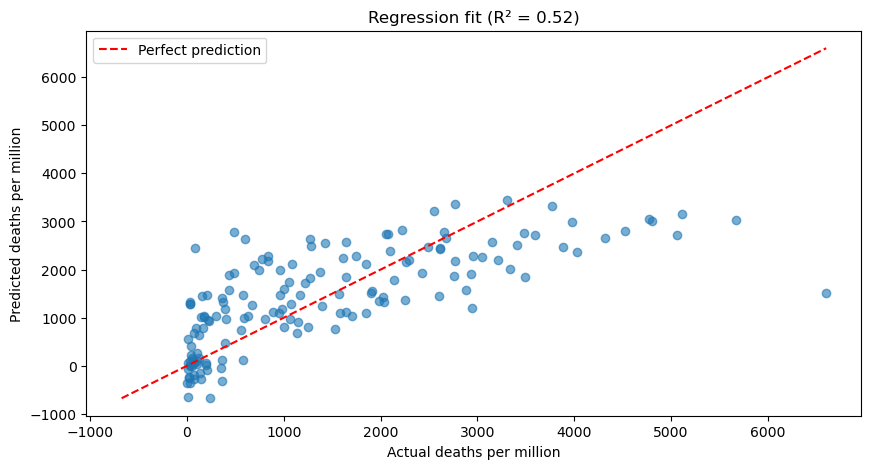

In [30]:
# Visualize predicted vs actual
predictions = model.predict(X_reg)

plt.scatter(y_reg, predictions, alpha=0.6)
lims = [min(y_reg.min(), predictions.min()), max(y_reg.max(), predictions.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual deaths per million')
plt.ylabel('Predicted deaths per million')
plt.title(f'Regression fit (R² = {model.rsquared:.2f})')
plt.legend()
plt.show()


## 9. Export cleaned & merged data

In [31]:
timeseries_countries.to_csv('covid_timeseries_countries_cleaned.csv', index=False)
country_context.to_csv('country_context_cleaned.csv', index=False)
merged.to_csv('covid_full_merged.csv', index=False)
print('Saved: covid_timeseries_countries_cleaned.csv, country_context_cleaned.csv, covid_full_merged.csv')


Saved: covid_timeseries_countries_cleaned.csv, country_context_cleaned.csv, covid_full_merged.csv


In [33]:
import json

# --- Country snapshot (for scatter + bar chart) ---
# 'latest' = one row per country with their most recent stats
# 'cluster_df' = the clustered subset from the k-means section, has the 'cluster' column
snapshot = latest.merge(cluster_df[['cluster']], left_index=True, right_index=True, how='left')
snapshot = snapshot.reset_index()  # 'location' is currently the index, so pull it out into a column

snapshot_cols = ['location','continent','population','gdp_per_capita','total_deaths_per_million','total_cases_per_million','cluster']
countries_json = snapshot[snapshot_cols].rename(columns={
    'total_deaths_per_million': 'deaths_pm',
    'total_cases_per_million': 'cases_pm'
}).to_dict('records')

# --- Monthly time series (for line charts) ---
selected_countries = ['United States','India','Brazil','United Kingdom','France','Germany',
                       'China','Japan','South Korea','Canada','Mexico','South Africa','Nigeria']

timeseries_json = {}
for loc in selected_countries:
    sub = merged[merged['location'] == loc].sort_values('date')
    sub_monthly = sub.set_index('date')[['total_cases_per_million','total_deaths_per_million']].resample('MS').last().reset_index()
    timeseries_json[loc] = {
        'dates': sub_monthly['date'].dt.strftime('%Y-%m').tolist(),
        'cases_pm': sub_monthly['total_cases_per_million'].where(sub_monthly['total_cases_per_million'].notna(), None).tolist(),
        'deaths_pm': sub_monthly['total_deaths_per_million'].where(sub_monthly['total_deaths_per_million'].notna(), None).tolist(),
    }

print(json.dumps({'countries': countries_json, 'timeseries': timeseries_json}))

{"countries": [{"location": "Lesotho", "continent": "Africa", "population": 2142252.0, "gdp_per_capita": 2851.153, "deaths_pm": 310.134, "cases_pm": 15807.624, "cluster": NaN}, {"location": "Yemen", "continent": "Asia", "population": 29825968.0, "gdp_per_capita": 1479.147, "deaths_pm": 56.484, "cases_pm": 312.509, "cluster": 3.0}, {"location": "Grenada", "continent": "North America", "population": 112519.0, "gdp_per_capita": 13593.877, "deaths_pm": 2035.441, "cases_pm": 168419.88, "cluster": 0.0}, {"location": "Greenland", "continent": "North America", "population": 56772.0, "gdp_per_capita": NaN, "deaths_pm": 374.906, "cases_pm": 213714.42, "cluster": NaN}, {"location": "Greece", "continent": "Europe", "population": 10423056.0, "gdp_per_capita": 24574.382, "deaths_pm": 3770.283, "cases_pm": 544892.3, "cluster": 1.0}, {"location": "Gibraltar", "continent": "Europe", "population": 33691.0, "gdp_per_capita": NaN, "deaths_pm": 3002.844, "cases_pm": 546092.3, "cluster": NaN}, {"location": 